# 05 · City-Level Analysis

One row per country × city per month — the finest geographic breakdown without
requiring an ISP filter.

## Caveats

- **Uneven coverage** — large cities in high-connectivity countries have thousands
  of tests; small towns may have zero. Use the minimum sample count filter.
- **Geolocation accuracy** — city assignments come from MaxMind GeoIP2, accurate to
  city level but not to neighbourhood. Some tests may be misattributed.
- **Statistical noise** — cities with fewer than ~100–200 tests may show extreme
  percentile values that are artefacts of small sample size, not real differences.

## Setup

In [1]:
import json
from pathlib import Path

import pandas as pd
import requests

try:
    import ipywidgets as widgets
    import matplotlib.pyplot as plt
    import matplotlib.ticker as mticker
    import seaborn as sns
    from IPython.display import clear_output, display
    sns.set_theme(style="whitegrid", palette="muted")
    plt.rcParams["figure.figsize"] = (12, 5)
except ImportError as e:
    print(f"Note: {e}")
    print("  Install with: uv add matplotlib seaborn ipywidgets")


In [2]:
# ── Country name lookup ──────────────────────────────────────────────────────
# countrylookup.py is a local helper (same directory as this notebook) that
# converts ISO 3166-1 alpha-2 codes to readable English country names.
# It tries pycountry → restcountries.com API → built-in fallback dict.
#
# If you move this notebook, keep countrylookup.py alongside it.
import sys, pathlib
sys.path.insert(0, str(pathlib.Path().resolve()))  # ensure local module is found
from countrylookup import cc_name, cc_label

print(f"Country lookup ready — {cc_label('US')}, {cc_label('KR')}, {cc_label('XK')}")

[countrylookup] downloading country names from restcountries.com ...
Country lookup ready — United States (US), South Korea (KR), Kosovo (XK)


In [3]:
# ── Discover available months ─────────────────────────────────────────────────
#
# Fetch the M-Lab manifest to learn which months are available per slice.
# Each entry includes the public download URL and the local cache path.

MANIFEST_URL = "https://measurementlab.net/data/iqb/manifest.json"
resp = requests.get(MANIFEST_URL, timeout=30)
resp.raise_for_status()

records = []
for path, meta in resp.json()["files"].items():
    parts = path.split("/")
    if len(parts) >= 6 and parts[5] == "data.parquet":
        records.append({
            "start":      pd.to_datetime(parts[2], format="%Y%m%dT%H%M%SZ"),
            "slice":      parts[4],
            "url":        meta["url"],
            "cache_path": path,
        })

catalog = (
    pd.DataFrame(records)
    .sort_values(["slice", "start"])
    .reset_index(drop=True)
)

print(f"Catalog: {len(catalog)} entries, {catalog['slice'].nunique()} slices, "
      f"{catalog['start'].min().date()} → {catalog['start'].max().date()}")


Catalog: 2450 entries, 12 slices, 2009-01-01 → 2026-01-01


In [4]:
# ── Data loader ──────────────────────────────────────────────────────────────
#
# Downloads parquet files from the public M-Lab URLs in the manifest.
# Files are cached to ./cache/v1/... on first access and reused on subsequent
# runs (matching the path structure used by the iqb library's local cache).

from io import BytesIO

_mem_cache: dict = {}

def load_parquet(slice_name: str, start: str) -> pd.DataFrame:
    key = (slice_name, start)
    if key in _mem_cache:
        return _mem_cache[key]

    start_ts = pd.to_datetime(start)
    row = catalog[(catalog["slice"] == slice_name) & (catalog["start"] == start_ts)]
    if row.empty:
        available = catalog[catalog["slice"] == slice_name]["start"].dt.strftime("%Y-%m-%d").tolist()
        raise ValueError(f"No data for slice='{slice_name}', month='{start}'.\nAvailable: {available}")
    row = row.iloc[0]

    local_path = Path(row["cache_path"])
    if local_path.exists():
        df = pd.read_parquet(local_path)
    else:
        print(f"[download] {slice_name} / {start} …")
        r = requests.get(row["url"], timeout=60)
        r.raise_for_status()
        local_path.parent.mkdir(parents=True, exist_ok=True)
        local_path.write_bytes(r.content)
        df = pd.read_parquet(BytesIO(r.content))
        print(f"  ✓ saved to {local_path}  ({len(df):,} rows)")

    _mem_cache[key] = df
    return df


## Interactive City Explorer

Raise the minimum sample count to focus on large, well-measured cities; lower it
to reveal smaller cities at the cost of noisier estimates.

In [5]:
city_months = sorted(
    catalog[catalog["slice"] == "downloads_by_country_city"]["start"]
    .dt.strftime("%Y-%m-%d").unique(), reverse=True,
)

# Metric options: display label → (column name, lower_is_better)
# Latency and loss: lower raw values are better, but IQB's polarity inversion
# means higher percentiles represent the better-performing connections.
METRICS = {
    "Download p50 (Mbit/s)":       ("download_p50",  False),
    "Upload p50 (Mbit/s)":         ("upload_p50",    False),
    "Latency p50 (ms)":            ("latency_p50",   True),
    "Packet Loss p50 (fraction)":  ("loss_p50",      True),
}

w_month   = widgets.Dropdown(options=city_months, description="Month:",
                              layout=widgets.Layout(width="250px"))
w_country = widgets.Dropdown(options=[],          description="Country:",
                              layout=widgets.Layout(width="200px"))
w_min_s   = widgets.IntSlider(value=200, min=10, max=5000, step=50,
                               description="Min samples:", layout=widgets.Layout(width="420px"))
w_topn    = widgets.IntSlider(value=20, min=5, max=60, step=5,
                               description="Top N:", layout=widgets.Layout(width="420px"))
w_metric  = widgets.Dropdown(options=list(METRICS), description="Metric:",
                              layout=widgets.Layout(width="290px"))
out       = widgets.Output()

_city: dict = {}
def _load_city(month):
    if month not in _city:
        _city[month] = load_parquet("downloads_by_country_city", month)
    return _city[month]

def on_month(change):
    df = _load_city(change["new"])
    cc = sorted(df["country_code"].dropna().unique())
    w_country.options = cc; w_country.value = "US" if "US" in cc else cc[0]
    draw()

def draw(change=None):
    month, country = w_month.value, w_country.value
    if not country: return
    col, lower = METRICS[w_metric.value]
    df = _load_city(month)
    filt = df[(df["country_code"]==country) & (df["sample_count"]>=w_min_s.value)]
    top = filt.nsmallest(w_topn.value,col) if lower else filt.nlargest(w_topn.value,col)
    top = top.sort_values(col, ascending=not lower)
    with out:
        clear_output(wait=True)
        if top.empty:
            print(f"No cities in {country} with >= {w_min_s.value} samples. "
                  "Lower 'Min samples'."); return
        print(f"{len(filt):,} cities meet the threshold; showing top {w_topn.value}.")
        fig, ax = plt.subplots(figsize=(11,max(5,w_topn.value*0.38)))
        ax.barh(top["city"],top[col])
        ax.set_xlabel(w_metric.value)
        ax.set_title(f"Top {w_topn.value} cities — {cc_name(country)} — "
                     f"{w_metric.value} {'(lower=better)' if lower else ''}\n{month}")
        plt.tight_layout(); plt.show()

w_month.observe(on_month,"value"); w_country.observe(draw,"value")
w_min_s.observe(draw,"value"); w_topn.observe(draw,"value"); w_metric.observe(draw,"value")
display(widgets.VBox([widgets.HBox([w_month,w_country,w_metric]),
                      widgets.HBox([w_min_s,w_topn]),out]))
on_month({"new": city_months[0]})

[download] downloads_by_country_city / 2025-12-01 …
  ✓ saved to cache/v1/20251201T000000Z/20260101T000000Z/downloads_by_country_city/data.parquet  (68,182 rows)


## Latency vs Packet Loss Scatter

These two metrics both reflect congestion but can diverge:
- **High latency, low loss** — often satellite or very long-haul paths
- **Low latency, high loss** — a congested last-mile link
- **Both high** — severely degraded path

Cities in the lower-left corner have the best overall network quality.
Point size encodes sample count; colour encodes median download speed.

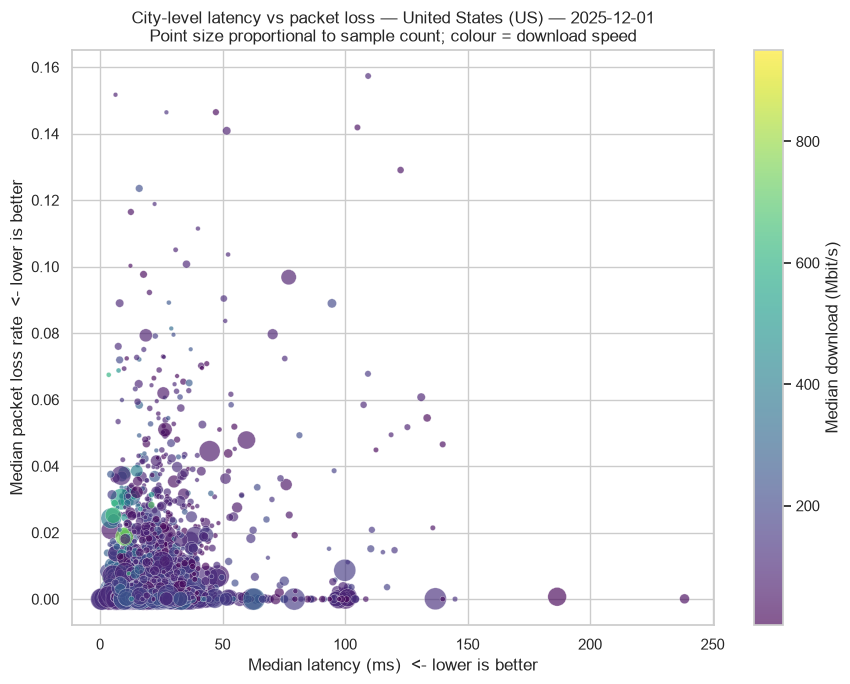

In [6]:
w_sm  = widgets.Dropdown(options=city_months, description="Month:",
                          layout=widgets.Layout(width="250px"))
w_sc  = widgets.Dropdown(options=[],          description="Country:",
                          layout=widgets.Layout(width="200px"))
w_sms = widgets.IntSlider(value=200, min=10, max=2000, step=50,
                           description="Min samples:", layout=widgets.Layout(width="400px"))
out_s = widgets.Output()

def on_sm(change):
    prev = w_sc.value
    df = _load_city(change["new"])
    cc = sorted(df["country_code"].dropna().unique())
    w_sc.options = [(cc_label(c), c) for c in cc]
    w_sc.value = prev if prev in cc else ("US" if "US" in cc else cc[0])
    draw_s()

def draw_s(change=None):
    df = _load_city(w_sm.value)
    filt = df[(df["country_code"]==w_sc.value) & (df["sample_count"]>=w_sms.value)]
    with out_s:
        clear_output(wait=True)
        if filt.empty: print("No cities meet the threshold. Lower Min samples."); return
        fig, ax = plt.subplots(figsize=(9,7))
        sc_plot = ax.scatter(filt["latency_p50"],filt["loss_p50"],
                             c=filt["download_p50"],cmap="viridis",
                             s=filt["sample_count"].clip(upper=5000)/20,
                             alpha=0.65,edgecolors="white",linewidths=0.3)
        plt.colorbar(sc_plot,ax=ax,label="Median download (Mbit/s)")
        ax.set_xlabel("Median latency (ms)  <- lower is better")
        ax.set_ylabel("Median packet loss rate  <- lower is better")
        ax.set_title(f"City-level latency vs packet loss — {cc_name(w_sc.value)} ({w_sc.value}) — {w_sm.value}\n"
                     "Point size proportional to sample count; colour = download speed")
        plt.tight_layout(); plt.show()

w_sm.observe(on_sm,"value"); w_sc.observe(draw_s,"value"); w_sms.observe(draw_s,"value")
display(widgets.VBox([widgets.HBox([w_sm,w_sc]),w_sms,out_s]))
on_sm({"new": city_months[0]})